In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Dataset1.csv')  # change filename as needed

# Check shape
print("Total Records:", df.shape[0])
print("Total Columns:", df.shape[1])
print("\nColumn Names:\n", df.columns.tolist())

# Quick peek
print("\nFirst 5 rows:")
df.head()

Total Records: 186074
Total Columns: 12

Column Names:
 ['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']

First 5 rows:


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [3]:
# Group by train number/name and get first & last station
train_table = df.groupby('Train_No').agg(
    Starting_Station=('Station_Name', 'first'),
    Ending_Station=('Station_Name', 'last')
).reset_index()

print(train_table)

       Train_No Starting_Station Ending_Station
0           107     SAWANTWADI R    MADGOAN JN.
1           108      MADGOAN JN.   SAWANTWADI R
2           128      MADGOAN JN.    CHHATRAPATI
3           290     DELHI-SAFDAR   DELHI-SAFDAR
4           401       AURANGABAD   VARANASI JN.
...         ...              ...            ...
11108     99904         PUNE JN.       TALEGAON
11109     99905         TALEGAON   SHIVAJINAGAR
11110     99906         PUNE JN.       TALEGAON
11111     99907         TALEGAON       PUNE JN.
11112     99908         PUNE JN.       TALEGAON

[11113 rows x 3 columns]


In [4]:
# Basic stats for distance
print("=== Distance Statistics ===")
print(df['Distance'].describe())

# Number of stops per train
stops_per_train = df.groupby('Train_No')['Station_Name'].count().reset_index()
stops_per_train.columns = ['Train_No', 'Number of Stops']

print("\n=== Stops Statistics ===")
print(stops_per_train['Number of Stops'].describe())
print("\nTrain-wise Stops:")
print(stops_per_train)

=== Distance Statistics ===
count    186074.000000
mean        281.353838
std         483.743964
min           0.000000
25%          23.000000
50%          73.000000
75%         291.000000
max        4260.000000
Name: Distance, dtype: float64

=== Stops Statistics ===
count    11113.000000
mean        16.743814
std         12.993123
min          2.000000
25%          8.000000
50%         15.000000
75%         22.000000
max        118.000000
Name: Number of Stops, dtype: float64

Train-wise Stops:
       Train_No  Number of Stops
0           107                4
1           108                4
2           128               22
3           290               14
4           401               12
...         ...              ...
11108     99904               12
11109     99905               11
11110     99906               12
11111     99907               12
11112     99908               12

[11113 rows x 2 columns]


In [5]:
# --- Missing Values ---
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

# --- Duplicate Rows ---
print("\n=== Duplicate Rows ===")
print(f"Total duplicate rows: {df.duplicated().sum()}")

# --- Data Types (helps spot incorrect values) ---
print("\n=== Data Types ===")
print(df.dtypes)

# --- Incorrect / Suspicious Values ---
# Check for negative distance values (if distance column exists)
print("\n=== Negative Distance Values ===")
print(df[df['Distance'] < 0])

# Check unique values in categorical columns
print("\n=== Unique values in key columns ===")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")

=== Missing Values ===
SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64

Total missing cells: 0

=== Duplicate Rows ===
Total duplicate rows: 0

=== Data Types ===
SN                 int64
Train_No           int64
Station_Code      object
1A                 int64
2A                 int64
3A                 int64
SL                 int64
Station_Name      object
Route_Number       int64
Arrival_time      object
Departure_Time    object
Distance           int64
dtype: object

=== Negative Distance Values ===
Empty DataFrame
Columns: [SN, Train_No, Station_Code, 1A, 2A, 3A, SL, Station_Name, Route_Number, Arrival_time, Departure_Time, Distance]
Index: []

=== Unique values in key columns ===
Station_Code: 8147 unique values
Station_Name: 8099 unique values
Arrival_time: 1440 unique values

In [7]:
# --- Drop duplicate rows ---
df = df.drop_duplicates()
print("Duplicates removed. Remaining records:", len(df))

# --- Handle missing values ---

# Check missing values per column
print("\nMissing values per column:")
print(df.isnull().sum())

# Option 1: Drop rows where critical columns are missing
critical_cols = ['Train_No', 'Station_Name', 'Arrival_time', 'Departure_Time', 'Distance']
df = df.dropna(subset=critical_cols)

# Option 2: Fill missing numeric values with median
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

# Option 3: Fill missing categorical values with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nAfter cleaning - Missing values:")
print(df.isnull().sum())
print("Total records after cleaning:", len(df))

Duplicates removed. Remaining records: 186074

Missing values per column:
SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64


C:\Users\New Hope\AppData\Local\Temp\ipykernel_3756\1716917427.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\New Hope\AppData\Local\Temp\ipykernel_3756\1716917427.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For


After cleaning - Missing values:
SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64
Total records after cleaning: 186074


In [8]:
# --- Convert time strings to datetime ---
# Times are usually in HH:MM format in train datasets

def convert_time_to_minutes(time_str):
    """Convert HH:MM time string to total minutes from midnight"""
    try:
        if pd.isna(time_str) or time_str in ['--', 'None', '']:
            return None
        parts = str(time_str).strip().split(':')
        hours = int(parts[0])
        minutes = int(parts[1])
        return hours * 60 + minutes
    except:
        return None

# Apply conversion
df['Arrival_Minutes']   = df['Arrival_time'].apply(convert_time_to_minutes)
df['Departure_Minutes'] = df['Departure_Time'].apply(convert_time_to_minutes)

# Extract additional time features
df['Departure_Hour'] = df['Departure_Minutes'] // 60   # hour of day (0-23)

# Time of day category (useful feature for ML)
def get_time_of_day(hour):
    if hour is None:
        return 'Unknown'
    elif 4 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_of_Day'] = df['Departure_Hour'].apply(get_time_of_day)

print("Time conversion done!")
print(df[['Arrival_time', 'Departure_Time', 'Arrival_Minutes', 'Departure_Minutes', 'Departure_Hour', 'Time_of_Day']].head(10))

Time conversion done!
  Arrival_time Departure_Time  Arrival_Minutes  Departure_Minutes  \
0     00:00:00       10:25:00                0                625   
1     11:06:00       11:08:00              666                668   
2     11:28:00       11:30:00              688                690   
3     12:10:00       00:00:00              730                  0   
4     00:00:00       20:30:00                0               1230   
5     21:04:00       21:06:00             1264               1266   
6     21:26:00       21:28:00             1286               1288   
7     22:25:00       00:00:00             1345                  0   
8     19:40:00       19:40:00             1180               1180   
9     20:18:00       20:20:00             1218               1220   

   Departure_Hour Time_of_Day  
0              10     Morning  
1              11     Morning  
2              11     Morning  
3               0       Night  
4              20     Evening  
5              21       Ni

In [11]:
# --- Calculate duration for each stop ---
# Duration at each segment = Arrival of next - Departure of current

# Sort by Train No and Stop number to ensure correct order
df = df.sort_values(by=['Train_No', 'Station_Code'])  # replace 'Stop No' with your actual stop order column

# Calculate per-train journey duration
def calculate_journey_duration(group):
    """For each train, duration = last arrival - first departure (in minutes)"""
    first_departure = group['Departure_Minutes'].iloc[0]
    last_arrival    = group['Arrival_Minutes'].iloc[-1]
    
    duration = last_arrival - first_departure
    
    # Handle overnight trains (crosses midnight)
    if duration < 0:
        duration += 24 * 60  # add 24 hours in minutes
    
    return duration

# Apply to each train group
journey_duration = df.groupby('Train_No').apply(calculate_journey_duration).reset_index()
journey_duration.columns = ['Train_No', 'Journey_Duration_Minutes']

print("Journey Duration per Train:")
print(journey_duration.head(10))

# Merge back to main dataframe
df = df.merge(journey_duration, on='Train_No', how='left')

# Also create a readable format (Hours and Minutes)
journey_duration['Duration_Hours']   = journey_duration['Journey_Duration_Minutes'] // 60
journey_duration['Duration_Minutes'] = journey_duration['Journey_Duration_Minutes'] % 60

print("\nJourney Duration Summary:")
print(journey_duration[['Train_No', 'Journey_Duration_Minutes', 'Duration_Hours', 'Duration_Minutes']].head(10))

Journey Duration per Train:
   Train_No  Journey_Duration_Minutes
0       107                      1416
1       108                        20
2       128                      1288
3       290                       750
4       401                       580
5       421                      1333
6       422                       495
7       477                      1380
8       502                       775
9       504                      1380

Journey Duration Summary:
   Train_No  Journey_Duration_Minutes  Duration_Hours  Duration_Minutes
0       107                      1416              23                36
1       108                        20               0                20
2       128                      1288              21                28
3       290                       750              12                30
4       401                       580               9                40
5       421                      1333              22                13
6       422            

C:\Users\New Hope\AppData\Local\Temp\ipykernel_3756\309323302.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  journey_duration = df.groupby('Train_No').apply(calculate_journey_duration).reset_index()


In [12]:
# --- Aggregate features per train ---

train_features = df.groupby('Train_No').agg(
    
    # Feature 1: Total distance of journey
    Total_Distance = ('Distance', 'max'),         # max cumulative distance = total
    
    # Feature 2: Total number of stops
    Total_Stops = ('Station_Name', 'count'),
    
    # Feature 3: Starting station
    Start_Station = ('Station_Name', 'first'),
    
    # Feature 4: Ending station
    End_Station = ('Station_Name', 'last'),
    
    # Feature 5: Departure hour (from first station)
    Departure_Hour = ('Departure_Hour', 'first'),
    
    # Feature 6: Time of day category
    Time_of_Day = ('Time_of_Day', 'first'),

).reset_index()

# Merge journey duration (target variable) into features table
train_features = train_features.merge(journey_duration[['Train_No', 'Journey_Duration_Minutes']], on='Train_No', how='left')

# --- Encode categorical column 'Time_of_Day' for ML ---
train_features = pd.get_dummies(train_features, columns=['Time_of_Day'], drop_first=True)

print("Final Feature Table:")
print(train_features.head())
print("\nShape:", train_features.shape)
print("\nColumns:", train_features.columns.tolist())

# --- Save cleaned feature dataset ---
train_features.to_csv('train_features_cleaned.csv', index=False)
print("\nCleaned dataset saved as 'train_features_cleaned.csv'")

Final Feature Table:
   Train_No  Total_Distance  Total_Stops Start_Station   End_Station  \
0       107              78            4       KARMALI        THIVIM   
1       108              83            4       KARMALI        THIVIM   
2       128             978           22       CHIPLUN   VAIBHAVWADI   
3       290            2694           14    AGRA CANTT  UDAIPUR CITY   
4       401            1618           12    AURANGABAD  SHAHGANJ JN.   

   Departure_Hour  Journey_Duration_Minutes  Time_of_Day_Evening  \
0              11                      1416                False   
1              21                        20                False   
2               1                      1288                False   
3              19                       750                 True   
4              21                       580                False   

   Time_of_Day_Morning  Time_of_Day_Night  
0                 True              False  
1                False               True  
2    

C:\Users\New Hope\AppData\Local\Temp\ipykernel_3756\432840150.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_avg = df.groupby('Distance_Bucket')['Journey_Duration_Minutes'].mean().reset_index()
C:\Users\New Hope\AppData\Local\Temp\ipykernel_3756\432840150.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


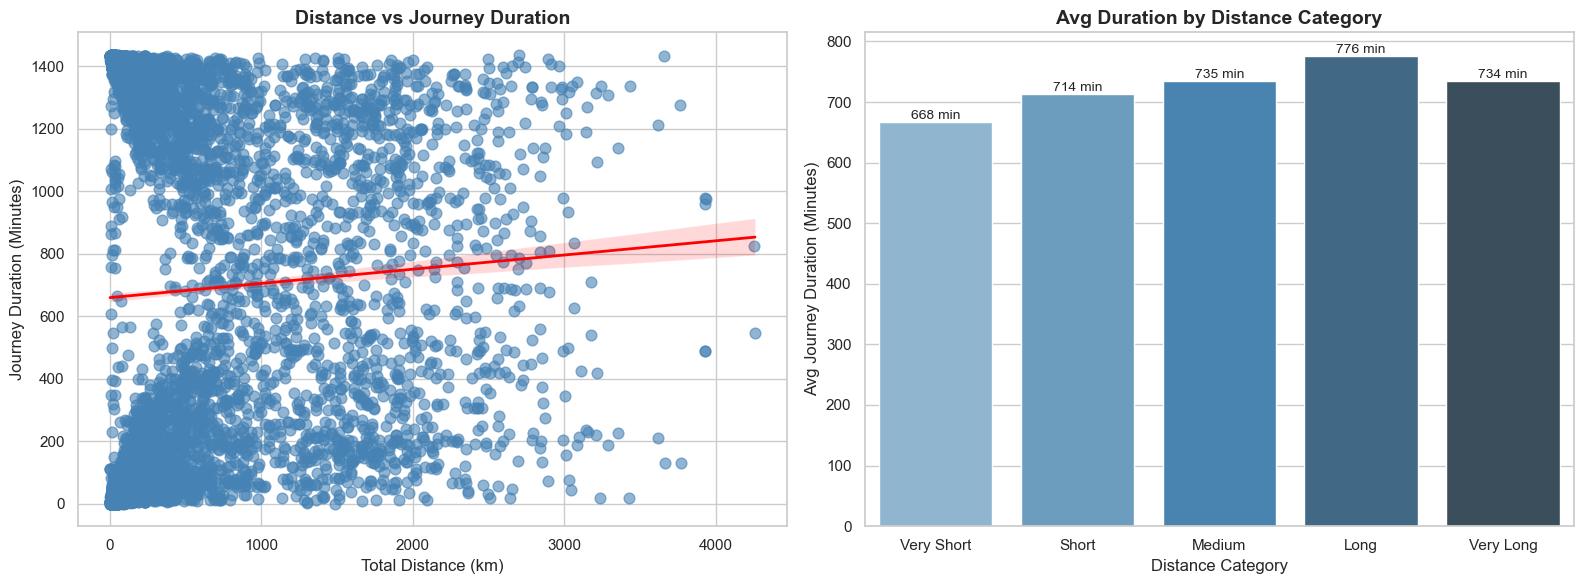

Plot saved!


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your cleaned feature dataset from Level 2
df = pd.read_csv('train_features_cleaned.csv')

# Global plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Scatter Plot with Regression Line ---
sns.regplot(
    data=df,
    x='Total_Distance',
    y='Journey_Duration_Minutes',
    ax=axes[0],
    scatter_kws={'alpha': 0.6, 'color': 'steelblue', 's': 60},
    line_kws={'color': 'red', 'linewidth': 2}
)
axes[0].set_title('Distance vs Journey Duration', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Distance (km)')
axes[0].set_ylabel('Journey Duration (Minutes)')

# --- Plot 2: Distance Buckets vs Avg Duration (Bar Chart) ---
df['Distance_Bucket'] = pd.cut(
    df['Total_Distance'],
    bins=5,
    labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
)

bucket_avg = df.groupby('Distance_Bucket')['Journey_Duration_Minutes'].mean().reset_index()

sns.barplot(
    data=bucket_avg,
    x='Distance_Bucket',
    y='Journey_Duration_Minutes',
    ax=axes[1],
    palette='Blues_d'
)
axes[1].set_title('Avg Duration by Distance Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Distance Category')
axes[1].set_ylabel('Avg Journey Duration (Minutes)')

# Add value labels on bars
for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():.0f} min',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.savefig('task3_1_distance_vs_duration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

C:\Users\New Hope\AppData\Local\Temp\ipykernel_3756\4019874679.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


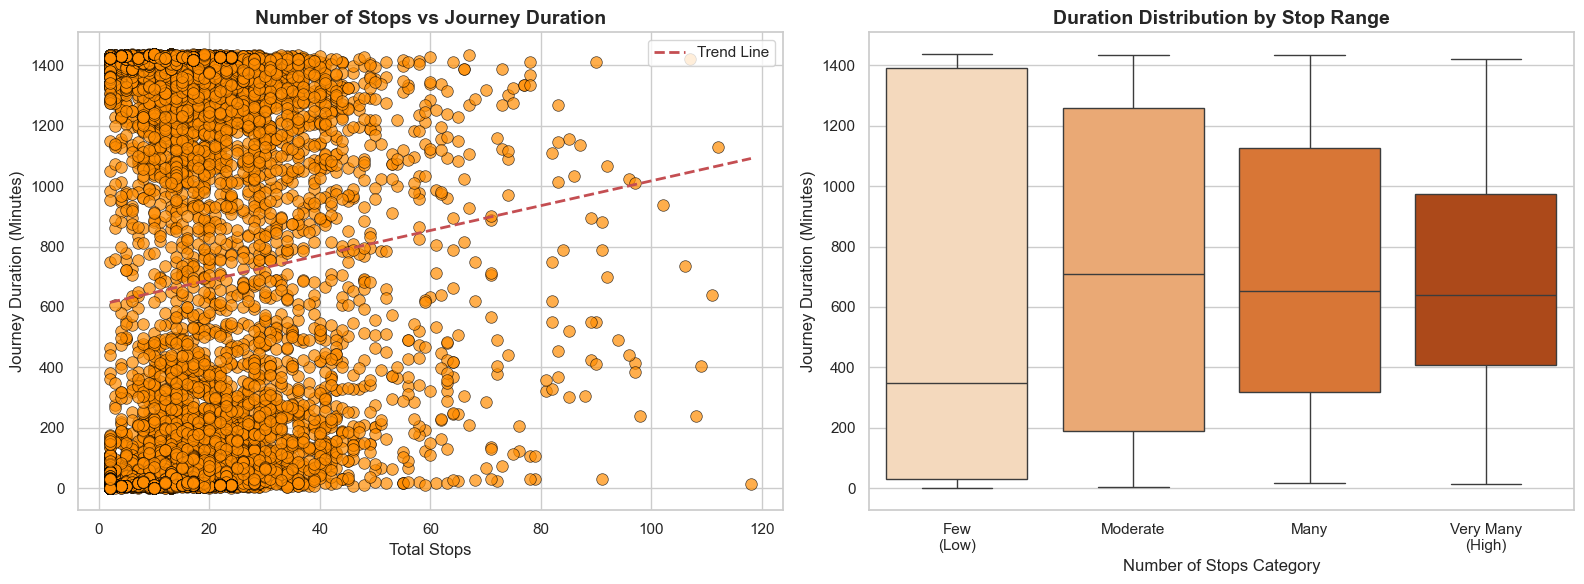

Plot saved!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Scatter Plot ---
sns.scatterplot(
    data=df,
    x='Total_Stops',
    y='Journey_Duration_Minutes',
    ax=axes[0],
    color='darkorange',
    alpha=0.7,
    s=70,
    edgecolor='black',
    linewidth=0.5
)

# Add trend line
z = np.polyfit(df['Total_Stops'].dropna(), df['Journey_Duration_Minutes'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['Total_Stops'].min(), df['Total_Stops'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend Line')
axes[0].legend()
axes[0].set_title('Number of Stops vs Journey Duration', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Stops')
axes[0].set_ylabel('Journey Duration (Minutes)')

# --- Plot 2: Box Plot by Stop Range ---
df['Stop_Range'] = pd.cut(
    df['Total_Stops'],
    bins=4,
    labels=['Few\n(Low)', 'Moderate', 'Many', 'Very Many\n(High)']
)

sns.boxplot(
    data=df,
    x='Stop_Range',
    y='Journey_Duration_Minutes',
    ax=axes[1],
    palette='Oranges'
)
axes[1].set_title('Duration Distribution by Stop Range', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Stops Category')
axes[1].set_ylabel('Journey Duration (Minutes)')

plt.tight_layout()
plt.savefig('task3_2_stops_vs_duration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

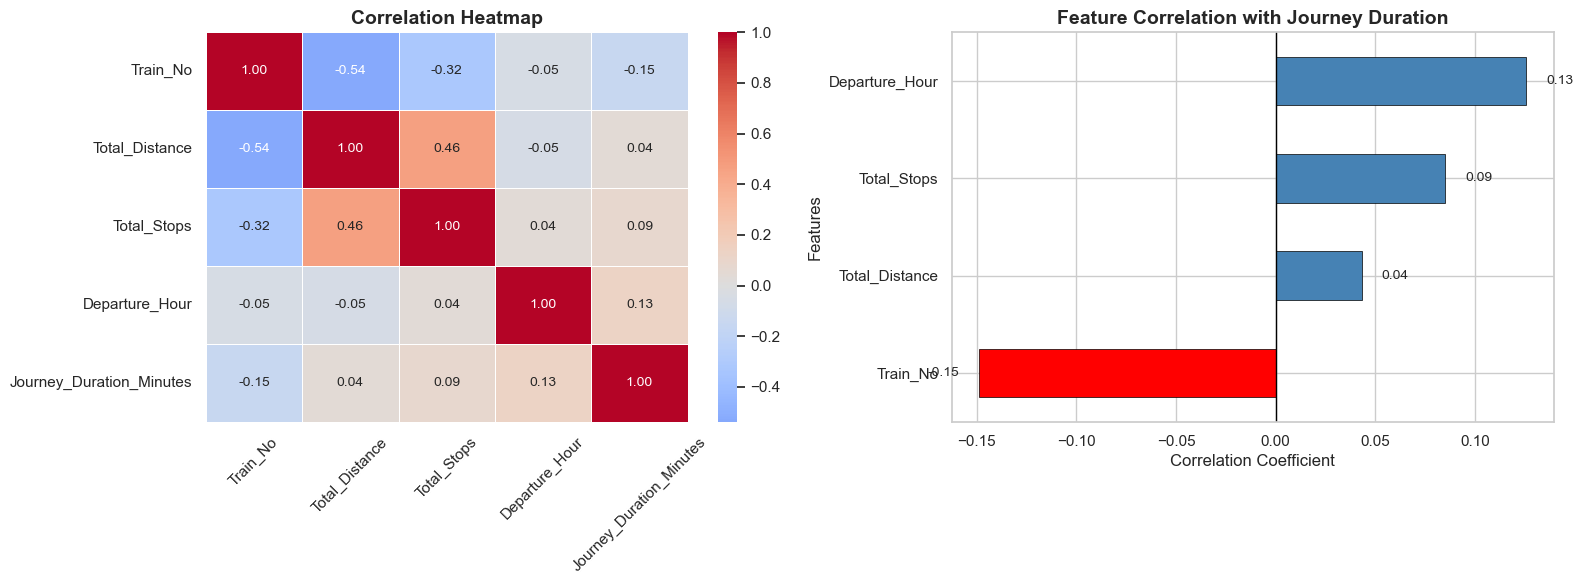

Plot saved!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Select only numeric columns ---
numeric_df = df.select_dtypes(include='number')

# --- Plot 1: Heatmap of Correlation Matrix ---
corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=axes[0],
    linewidths=0.5,
    annot_kws={'size': 10}
)
axes[0].set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# --- Plot 2: Bar Chart — Correlation of Each Feature with Target ---
target_corr = corr_matrix['Journey_Duration_Minutes'].drop('Journey_Duration_Minutes').sort_values()

colors = ['red' if v < 0 else 'steelblue' for v in target_corr.values]

target_corr.plot(
    kind='barh',
    ax=axes[1],
    color=colors,
    edgecolor='black',
    linewidth=0.5
)
axes[1].set_title('Feature Correlation with Journey Duration', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].set_ylabel('Features')
axes[1].axvline(x=0, color='black', linewidth=1)

# Add value labels
for i, (val, patch) in enumerate(zip(target_corr.values, axes[1].patches)):
    axes[1].text(
        val + 0.01 if val >= 0 else val - 0.01,
        patch.get_y() + patch.get_height() / 2,
        f'{val:.2f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=10
    )

plt.tight_layout()
plt.savefig('task3_3_correlation_visuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [18]:
# --- Build Pivot Table ---
pivot_table = df.pivot_table(
    values=['Total_Stops', 'Total_Distance', 'Journey_Duration_Minutes'],
    index='Train_No',
    aggfunc={
        'Total_Stops': 'sum',
        'Total_Distance': 'max',
        'Journey_Duration_Minutes': 'mean'
    }
).reset_index()

# Rename columns for clarity
pivot_table.columns = ['Train_No', 'Journey Duration (Mins)', 'Total Distance (km)', 'Total Stops']

# Sort by Total Stops
pivot_table = pivot_table.sort_values('Total Stops', ascending=False)

print("=== Pivot Table: Train-wise Summary ===")
print(pivot_table.to_string(index=False))

# --- Visualize Pivot Table as Heatmap ---
pivot_viz = pivot_table.set_index('Train No')

plt.figure(figsize=(10, max(6, len(pivot_viz) * 0.4)))

sns.heatmap(
    pivot_viz,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Train-wise Summary Heatmap\n(Stops, Distance, Duration)', fontsize=14, fontweight='bold')
plt.ylabel('Train No')
plt.tight_layout()
plt.savefig('task3_4_pivot_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Save pivot table to CSV ---
pivot_table.to_csv('train_pivot_summary.csv', index=False)
print("\nPivot table saved as 'train_pivot_summary.csv'")

=== Pivot Table: Train-wise Summary ===
 Train_No  Journey Duration (Mins)  Total Distance (km)  Total Stops
    53041                     13.0                  718          118
    13007                   1129.0                 1949          112
    13049                    641.0                 1908          111
    58112                    403.0                  883          109
    13008                    240.0                 1952          108
    53042                   1422.0                  718          107
    13050                    736.0                 1909          106
    58111                    937.0                  885          102
    19019                    238.0                 1676           98
    19024                    385.0                 1762           97
    13152                    415.0                 1979           97
    13352                   1011.0                 2534           97
    13351                    441.0                 2535        

KeyError: "None of ['Train No'] are in the columns"

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load cleaned feature dataset from Level 2
df = pd.read_csv('train_features_cleaned.csv')

sns.set_theme(style="whitegrid")
print("Dataset loaded! Shape:", df.shape)
print("Columns:", df.columns.tolist())

# --- Define Features (X) and Target (y) ---

# Drop non-numeric or identifier columns
drop_cols = ['Train_No', 'Start_Station', 'End_Station', 
             'Distance_Bucket', 'Stop_Range', 'Journey_Duration_Minutes']

# Keep only columns that exist in your dataframe
drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)          # Input features
y = df['Journey_Duration_Minutes']       # Target variable

# Keep only numeric columns in X
X = X.select_dtypes(include='number')

print("=== Features Used for Training ===")
print(X.columns.tolist())
print(f"\nFeature Matrix Shape : {X.shape}")
print(f"Target Variable Shape: {y.shape}")

# --- Handle any remaining missing values ---
X = X.fillna(X.median())
y = y.fillna(y.median())

# --- Scale Features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# --- Train/Test Split (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print(f"\n Training Set Size : {X_train.shape[0]} records")
print(f" Testing  Set Size : {X_test.shape[0]} records")

Dataset loaded! Shape: (11113, 10)
Columns: ['Train_No', 'Total_Distance', 'Total_Stops', 'Start_Station', 'End_Station', 'Departure_Hour', 'Journey_Duration_Minutes', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night']
=== Features Used for Training ===
['Total_Distance', 'Total_Stops', 'Departure_Hour']

Feature Matrix Shape : (11113, 3)
Target Variable Shape: (11113,)

 Training Set Size : 8890 records
 Testing  Set Size : 2223 records


=== Model Trained Successfully! ===

Feature Coefficients (Impact on Journey Duration):
       Feature  Coefficient
Departure_Hour    76.264972
   Total_Stops    43.310575
Total_Distance    11.936567

Intercept: 678.89


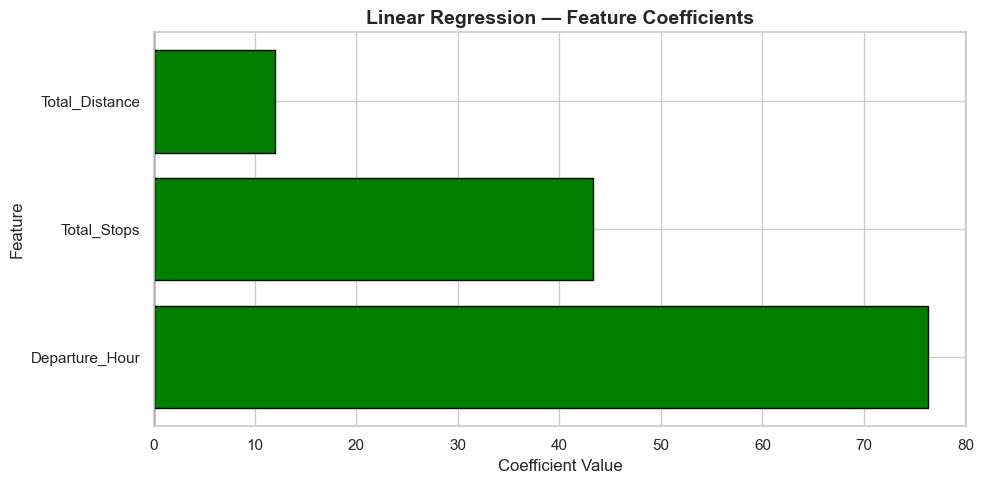

Coefficient plot saved!


In [22]:
# --- Train the Model ---
model = LinearRegression()
model.fit(X_train, y_train)

print("=== Model Trained Successfully! ===\n")

# --- Model Coefficients ---
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("Feature Coefficients (Impact on Journey Duration):")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.2f}")

# --- Visualize Feature Importance via Coefficients ---
plt.figure(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Linear Regression — Feature Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('task4_2_feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Coefficient plot saved!")

In [23]:
# --- Make Predictions ---
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# --- Calculate Metrics ---
mae_train  = mean_absolute_error(y_train, y_pred_train)
mae_test   = mean_absolute_error(y_test,  y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)

# --- Cross Validation Score ---
cv_scores = cross_val_score(
    LinearRegression(), X_scaled, y,
    cv=5, scoring='neg_mean_absolute_error'
)
cv_mae = -cv_scores.mean()

# --- Print Evaluation Report ---
print("=" * 45)
print("         MODEL EVALUATION REPORT")
print("=" * 45)
print(f"{'Metric':<25} {'Train':>8} {'Test':>8}")
print("-" * 45)
print(f"{'MAE  (Minutes)':<25} {mae_train:>8.2f} {mae_test:>8.2f}")
print(f"{'RMSE (Minutes)':<25} {rmse_train:>8.2f} {rmse_test:>8.2f}")
print(f"{'R² Score':<25} {r2_train:>8.4f} {r2_test:>8.4f}")
print("-" * 45)
print(f"{'Cross-Val MAE (5-Fold)':<25} {cv_mae:>8.2f}")
print("=" * 45)

# --- Interpret Results ---
print("\n=== Interpretation ===")
print(f"  MAE  = {mae_test:.2f} mins → avg prediction is off by {mae_test:.1f} minutes")
print(f"  RMSE = {rmse_test:.2f} mins → penalizes larger errors more heavily")
print(f"  R²   = {r2_test:.4f}  → model explains {r2_test*100:.1f}% of duration variance")

         MODEL EVALUATION REPORT
Metric                       Train     Test
---------------------------------------------
MAE  (Minutes)              596.95   596.53
RMSE (Minutes)              620.03   619.33
R² Score                    0.0218   0.0248
---------------------------------------------
Cross-Val MAE (5-Fold)      608.94

=== Interpretation ===
  MAE  = 596.53 mins → avg prediction is off by 596.5 minutes
  RMSE = 619.33 mins → penalizes larger errors more heavily
  R²   = 0.0248  → model explains 2.5% of duration variance


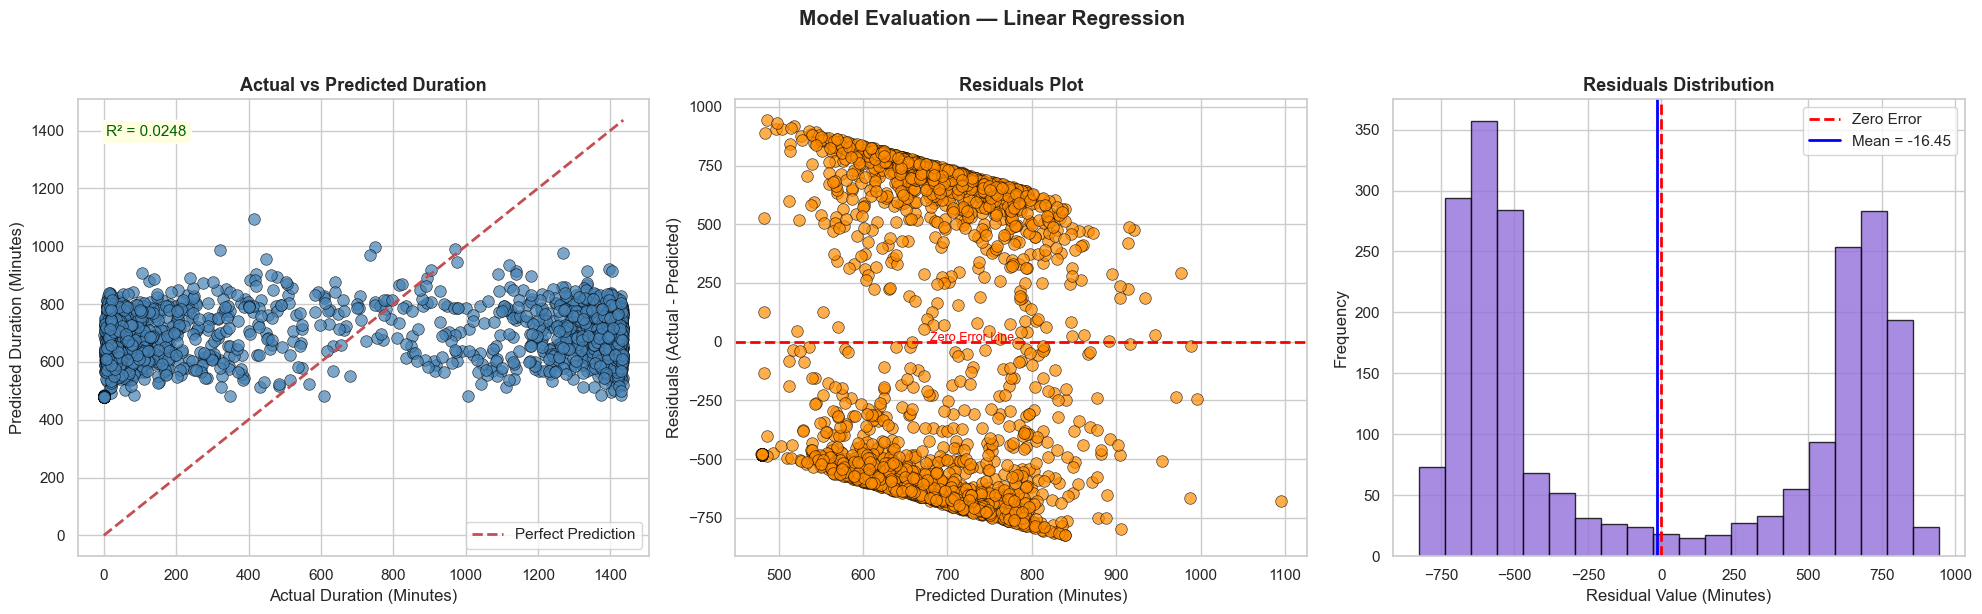

Evaluation plots saved!

=== Sample Predictions vs Actual (First 10) ===
 Actual Duration (Mins)  Predicted Duration (Mins)  Error (Mins)
                   1219                     625.04        593.96
                     41                     767.70       -726.70
                   1433                     663.20        769.80
                    918                     588.81        329.19
                     18                     684.04       -666.04
                     38                     683.84       -645.84
                    152                     623.11       -471.11
                      0                     480.37       -480.37
                    315                     746.91       -431.91
                    206                     738.48       -532.48


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Actual vs Predicted Scatter ---
axes[0].scatter(y_test, y_pred_test, alpha=0.7, color='steelblue',
                edgecolor='black', linewidth=0.5, s=70)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=2, label='Perfect Prediction')

axes[0].set_title('Actual vs Predicted Duration', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Duration (Minutes)')
axes[0].set_ylabel('Predicted Duration (Minutes)')
axes[0].legend()

# Add R² annotation
axes[0].annotate(f'R² = {r2_test:.4f}',
                 xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=11, color='darkgreen',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

# --- Plot 2: Residuals Plot (Error Distribution) ---
residuals = y_test.values - y_pred_test

axes[1].scatter(y_pred_test, residuals, alpha=0.7,
                color='darkorange', edgecolor='black', linewidth=0.5, s=70)
axes[1].axhline(y=0, color='red', linewidth=2, linestyle='--')
axes[1].set_title('Residuals Plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Duration (Minutes)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

# Add zero line annotation
axes[1].annotate('Zero Error Line',
                 xy=(y_pred_test.mean(), 2),
                 fontsize=9, color='red')

# --- Plot 3: Distribution of Residuals ---
axes[2].hist(residuals, bins=20, color='mediumpurple',
             edgecolor='black', alpha=0.8)
axes[2].axvline(x=0, color='red', linewidth=2, linestyle='--', label='Zero Error')
axes[2].axvline(x=residuals.mean(), color='blue', linewidth=2,
                linestyle='-', label=f'Mean = {residuals.mean():.2f}')
axes[2].set_title('Residuals Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Residual Value (Minutes)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Model Evaluation — Linear Regression', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task4_4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Evaluation plots saved!")

# --- Bonus: Side by side comparison table ---
comparison_df = pd.DataFrame({
    'Actual Duration (Mins)'   : y_test.values[:10],
    'Predicted Duration (Mins)': y_pred_test[:10].round(2),
    'Error (Mins)'             : residuals[:10].round(2)
})
print("\n=== Sample Predictions vs Actual (First 10) ===")
print(comparison_df.to_string(index=False))

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load cleaned dataset
df = pd.read_csv('train_features_cleaned.csv')

# Prepare full feature set
drop_cols = ['Train_No', 'Start_Station', 'End_Station',
             'Distance_Bucket', 'Stop_Range', 'Journey_Duration_Minutes']
drop_cols = [col for col in drop_cols if col in df.columns]

X_full = df.drop(columns=drop_cols).select_dtypes(include='number')
y      = df['Journey_Duration_Minutes']

X_full = X_full.fillna(X_full.median())
y      = y.fillna(y.median())

print("Dataset ready!")
print(f"Features available: {X_full.columns.tolist()}")
print(f"Total records     : {len(df)}")

# --- Use only the single strongest feature ---
# Find which single feature correlates most with target
correlations = X_full.corrwith(y).abs().sort_values(ascending=False)
best_feature  = correlations.index[0]

print("=== Feature Correlations with Journey Duration ===")
print(correlations)
print(f"\nBest single feature selected: '{best_feature}'")

# --- Prepare single feature dataset ---
X_single = X_full[[best_feature]]

scaler_single  = StandardScaler()
X_single_scaled = scaler_single.fit_transform(X_single)

# --- Split ---
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_single_scaled, y,
    test_size=0.2,
    random_state=42
)

# --- Train Basic Linear Regression ---
basic_model = LinearRegression()
basic_model.fit(X_train_s, y_train)

# --- Predict ---
y_pred_basic = basic_model.predict(X_test_s)

# --- Metrics ---
mae_basic  = mean_absolute_error(y_test, y_pred_basic)
rmse_basic = np.sqrt(mean_squared_error(y_test, y_pred_basic))
r2_basic   = r2_score(y_test, y_pred_basic)

cv_basic   = -cross_val_score(
    LinearRegression(), X_single_scaled, y,
    cv=5, scoring='neg_mean_absolute_error'
).mean()

print("\n" + "=" * 45)
print("     BASIC MODEL (Single Feature) RESULTS")
print("=" * 45)
print(f"  Feature Used : {best_feature}")
print(f"  MAE          : {mae_basic:.2f} minutes")
print(f"  RMSE         : {rmse_basic:.2f} minutes")
print(f"  R² Score     : {r2_basic:.4f}")
print(f"  CV MAE       : {cv_basic:.2f} minutes")
print("=" * 45)

Dataset ready!
Features available: ['Total_Distance', 'Total_Stops', 'Departure_Hour']
Total records     : 11113
=== Feature Correlations with Journey Duration ===
Departure_Hour    0.125759
Total_Stops       0.085085
Total_Distance    0.043209
dtype: float64

Best single feature selected: 'Departure_Hour'

     BASIC MODEL (Single Feature) RESULTS
  Feature Used : Departure_Hour
  MAE          : 599.96 minutes
  RMSE         : 621.88 minutes
  R² Score     : 0.0168
  CV MAE       : 607.33 minutes


In [28]:
# --- Scale full feature set ---
scaler_multi   = StandardScaler()
X_multi_scaled = scaler_multi.fit_transform(X_full)

# --- Split ---
X_train_m, X_test_m, y_train, y_test = train_test_split(
    X_multi_scaled, y,
    test_size=0.2,
    random_state=42
)

# --- Train 4 improved models ---
improved_models = {
    'Linear Regression\n(Multi-Feature)' : LinearRegression(),
    'Decision Tree'                       : DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest'                       : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'                   : GradientBoostingRegressor(n_estimators=100,
                                                                       learning_rate=0.1,
                                                                       max_depth=4,
                                                                       random_state=42)
}

improved_results = {}

print("=== Training Improved Models ===\n")

for name, mdl in improved_models.items():
    mdl.fit(X_train_m, y_train)
    preds = mdl.predict(X_test_m)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    cv   = -cross_val_score(mdl, X_multi_scaled, y,
                             cv=5, scoring='neg_mean_absolute_error').mean()

    improved_results[name] = {
        'model'     : mdl,
        'preds'     : preds,
        'MAE'       : round(mae,  2),
        'RMSE'      : round(rmse, 2),
        'R²'        : round(r2,   4),
        'CV MAE'    : round(cv,   2)
    }

    print(f"  {name.replace(chr(10), ' ')}")
    print(f"    MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}  CV MAE={cv:.2f}")
    print()

=== Training Improved Models ===

  Linear Regression (Multi-Feature)
    MAE=596.53  RMSE=619.33  R²=0.0248  CV MAE=608.94

  Decision Tree
    MAE=551.72  RMSE=599.02  R²=0.0877  CV MAE=608.42

  Random Forest
    MAE=567.20  RMSE=673.90  R²=-0.1546  CV MAE=598.40

  Gradient Boosting
    MAE=547.05  RMSE=593.19  R²=0.1054  CV MAE=597.50



              FULL MODEL COMPARISON TABLE
Model                                  MAE    RMSE      R²   CV MAE
----------------------------------------------------------------------
Basic Model (Departure_Hour only)   599.96  621.88  0.0168   607.33
Linear Regression (Multi-Feature)   596.53  619.33  0.0248   608.94
Decision Tree                       551.72  599.02  0.0877   608.42
Random Forest                       567.20  673.90 -0.1546   598.40
Gradient Boosting                   547.05  593.19  0.1054   597.50


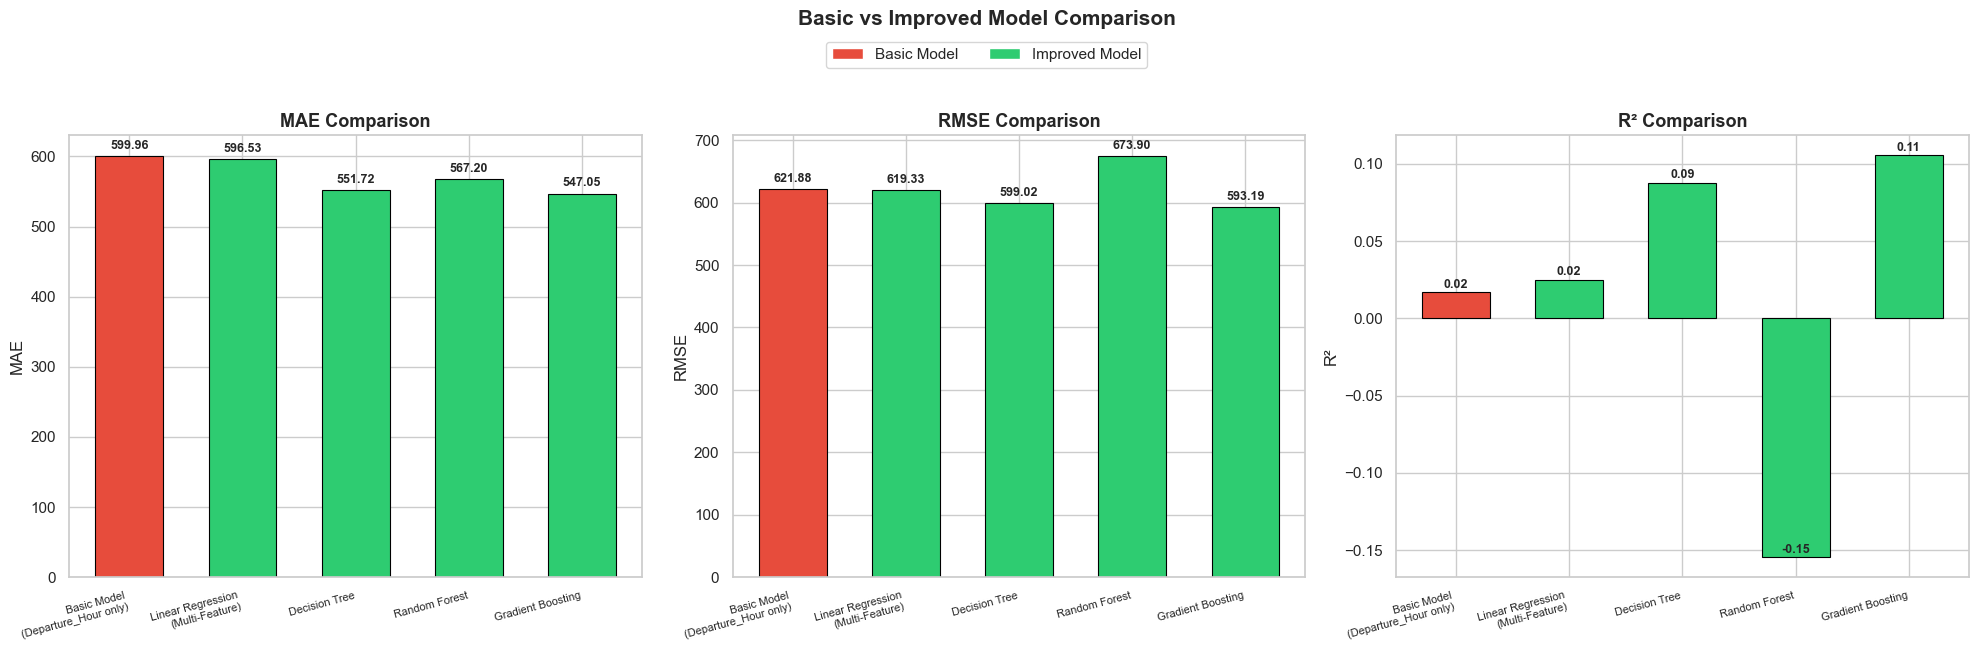

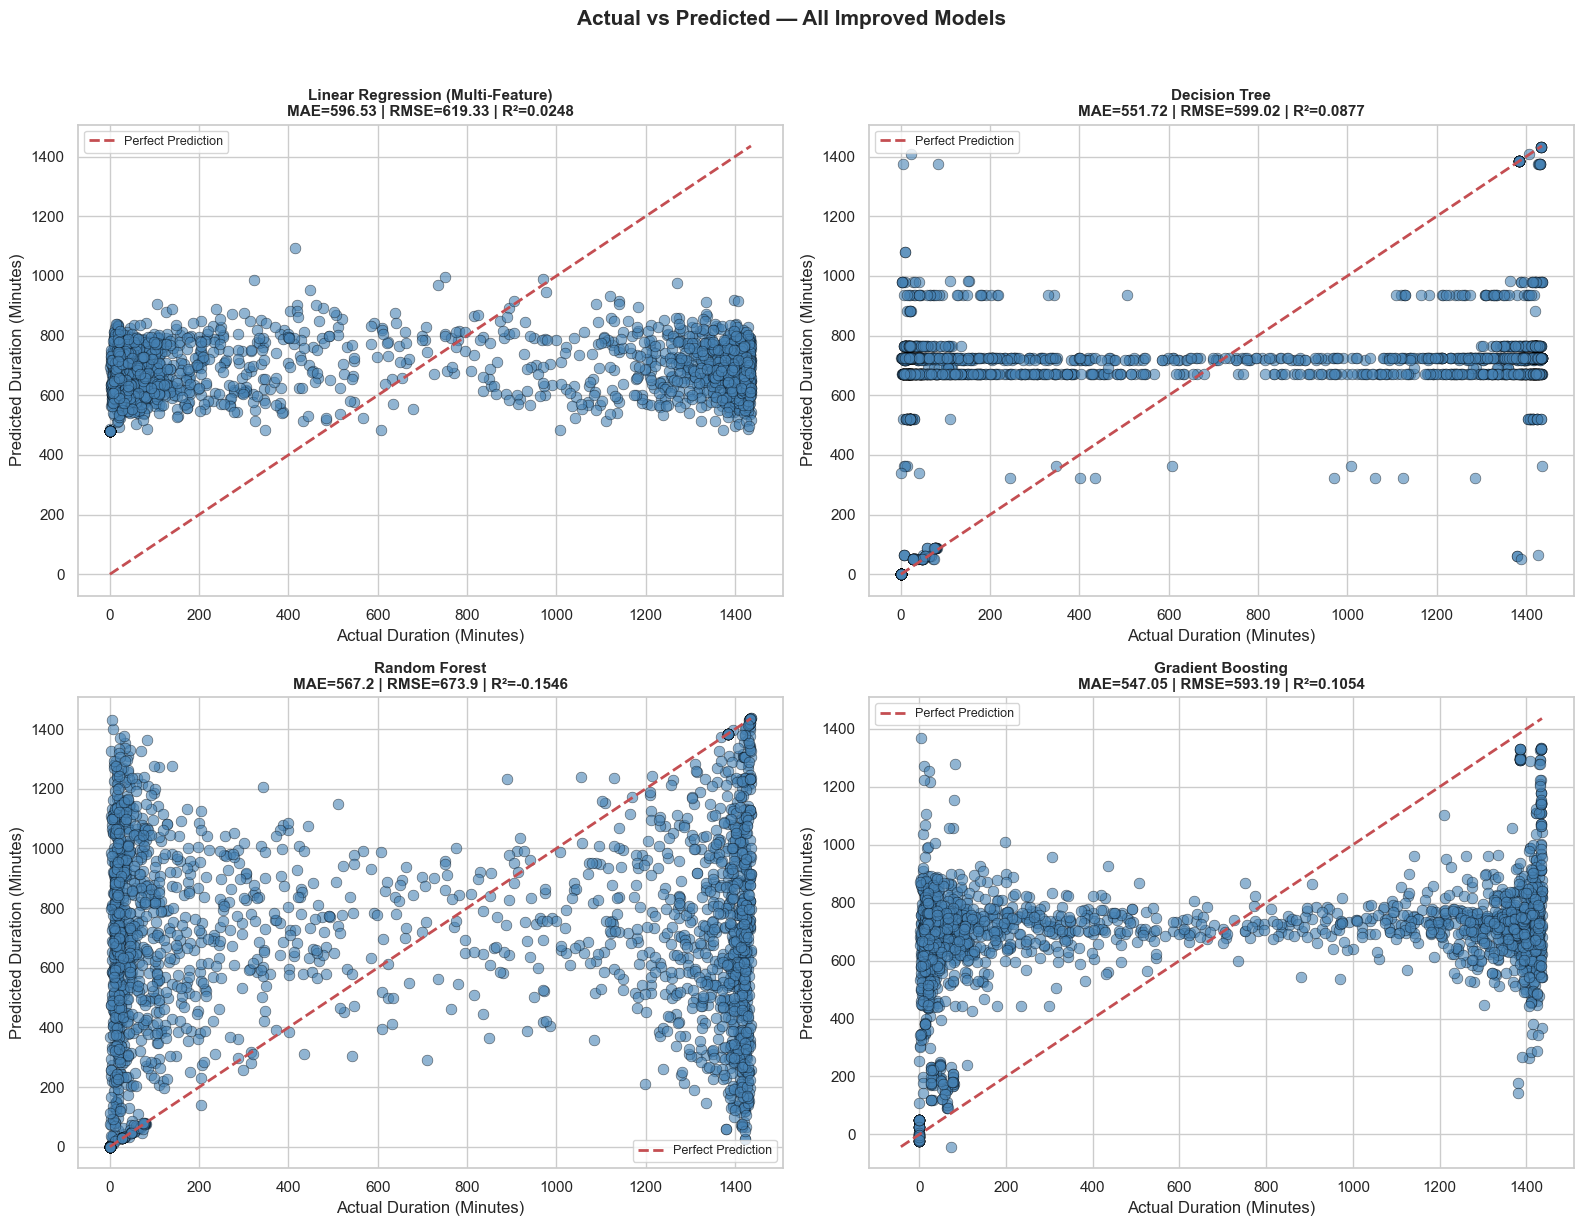

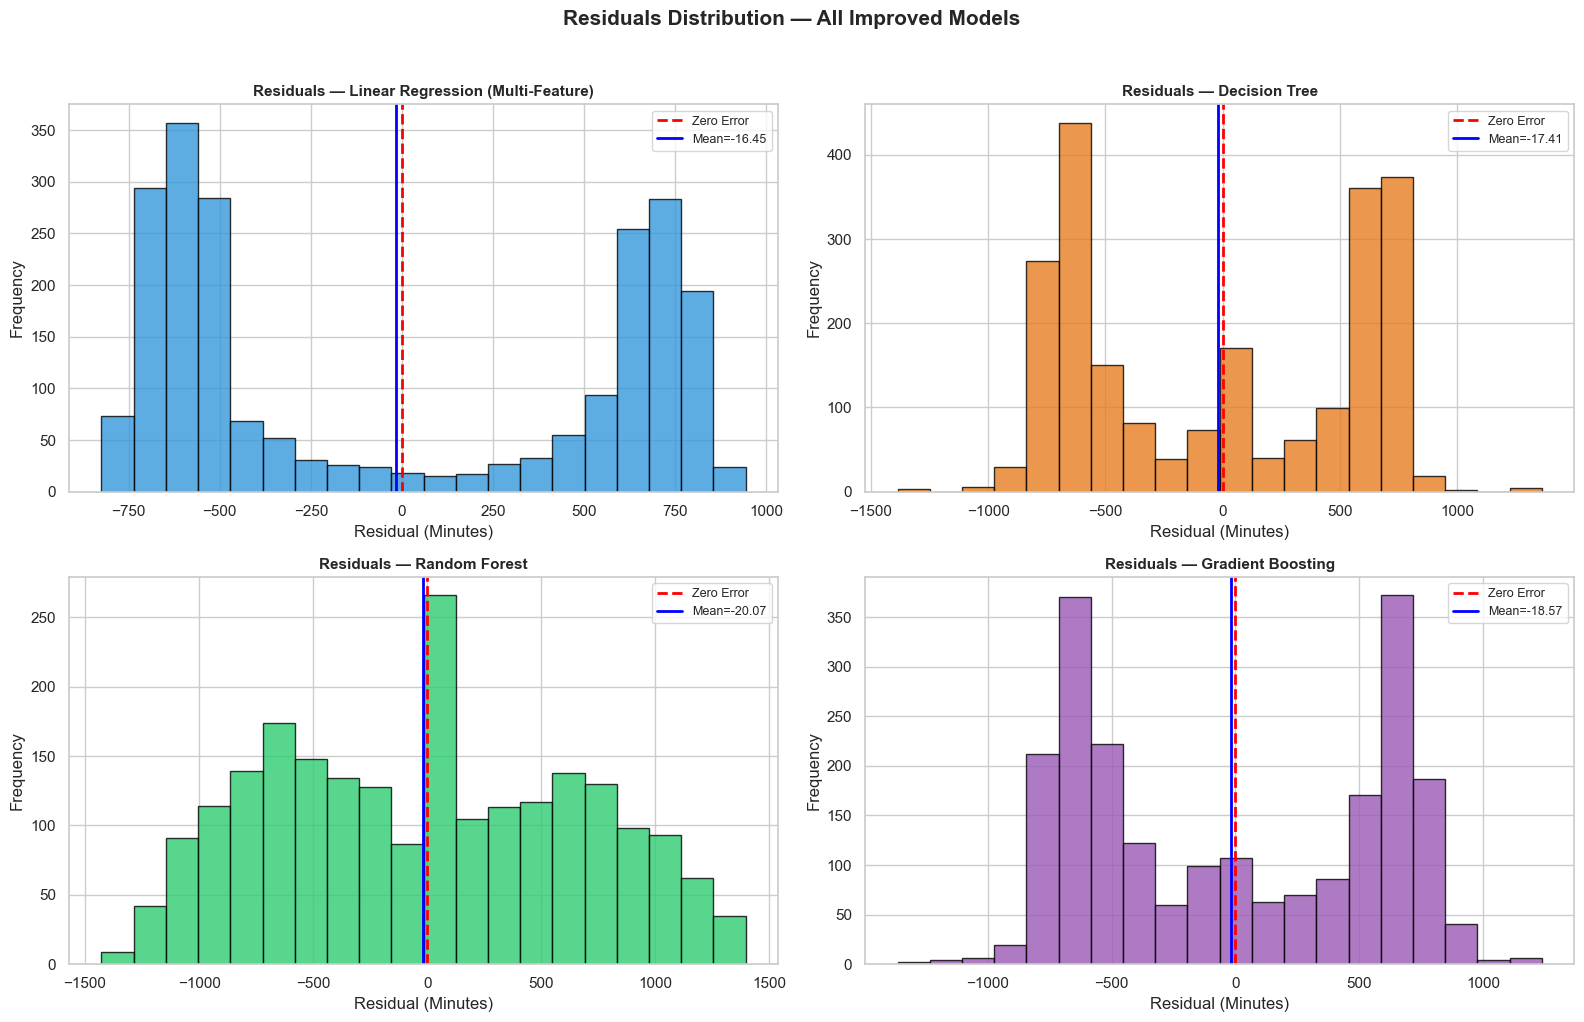

All comparison plots saved!


In [29]:
# --- Build comparison dataframe ---
# Add basic model to comparison
all_results = [{
    'Model'   : f'Basic Model\n({best_feature} only)',
    'MAE'     : round(mae_basic,  2),
    'RMSE'    : round(rmse_basic, 2),
    'R²'      : round(r2_basic,   4),
    'CV MAE'  : round(cv_basic,   2),
    'Type'    : 'Basic'
}]

for name, res in improved_results.items():
    all_results.append({
        'Model'  : name,
        'MAE'    : res['MAE'],
        'RMSE'   : res['RMSE'],
        'R²'     : res['R²'],
        'CV MAE' : res['CV MAE'],
        'Type'   : 'Improved'
    })

comparison_df = pd.DataFrame(all_results)

# --- Print full comparison table ---
print("=" * 70)
print("              FULL MODEL COMPARISON TABLE")
print("=" * 70)
print(f"{'Model':<35} {'MAE':>6} {'RMSE':>7} {'R²':>7} {'CV MAE':>8}")
print("-" * 70)
for _, row in comparison_df.iterrows():
    name = row['Model'].replace('\n', ' ')
    print(f"{name:<35} {row['MAE']:>6.2f} {row['RMSE']:>7.2f} {row['R²']:>7.4f} {row['CV MAE']:>8.2f}")
print("=" * 70)

# -------------------------------------------------------
# VISUAL 1 — Grouped Bar Chart: MAE & RMSE Comparison
# -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

model_labels = [m.replace('\n', '\n') for m in comparison_df['Model']]
colors       = ['#e74c3c' if t == 'Basic' else '#2ecc71'
                for t in comparison_df['Type']]

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    bars = ax.bar(range(len(comparison_df)), comparison_df[metric],
                  color=colors, edgecolor='black', linewidth=0.8, width=0.6)
    ax.set_xticks(range(len(comparison_df)))
    ax.set_xticklabels(model_labels, fontsize=8, rotation=15, ha='right')
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)

    # Value labels on bars
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + max(comparison_df[metric]) * 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Basic Model'),
                   Patch(facecolor='#2ecc71', label='Improved Model')]
fig.legend(handles=legend_elements, loc='upper center',
           ncol=2, fontsize=11, frameon=True,
           bbox_to_anchor=(0.5, 1.04))

plt.suptitle('Basic vs Improved Model Comparison', fontsize=15,
             fontweight='bold', y=1.08)
plt.tight_layout()
plt.savefig('task5_3_model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------
# VISUAL 2 — Actual vs Predicted for All Improved Models
# -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, res) in enumerate(improved_results.items()):
    ax = axes[idx]
    preds = res['preds']

    ax.scatter(y_test, preds, alpha=0.6, color='steelblue',
               edgecolor='black', linewidth=0.4, s=60)

    mn = min(y_test.min(), preds.min())
    mx = max(y_test.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')

    ax.set_title(f'{name.replace(chr(10), " ")}\nMAE={res["MAE"]} | RMSE={res["RMSE"]} | R²={res["R²"]}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual Duration (Minutes)')
    ax.set_ylabel('Predicted Duration (Minutes)')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted — All Improved Models', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task5_3_actual_vs_predicted_all.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------
# VISUAL 3 — Residuals Distribution Comparison
# -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

palette = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

for idx, (name, res) in enumerate(improved_results.items()):
    residuals = y_test.values - res['preds']
    ax = axes[idx]

    ax.hist(residuals, bins=20, color=palette[idx],
            edgecolor='black', alpha=0.8)
    ax.axvline(x=0,               color='red',  linewidth=2,
               linestyle='--', label='Zero Error')
    ax.axvline(x=residuals.mean(), color='blue', linewidth=2,
               linestyle='-',  label=f'Mean={residuals.mean():.2f}')
    ax.set_title(f'Residuals — {name.replace(chr(10), " ")}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Residual (Minutes)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Residuals Distribution — All Improved Models', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task5_3_residuals_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("All comparison plots saved!")


         BEST MODEL SELECTION REPORT

  Winner : Gradient Boosting
  MAE    : 547.05 minutes
  RMSE   : 593.19 minutes
  R²     : 0.1054
  CV MAE : 597.5 minutes

  Improvement over Basic Model:
    MAE  improved by : 8.8%
    RMSE improved by : 4.6%
    R²   improved by : 528.8%

=== Final Model Rankings (Improved Models) ===
 Rank                             Model    MAE   RMSE      R²  CV MAE
    1                 Gradient Boosting 547.05 593.19  0.1054  597.50
    2                     Decision Tree 551.72 599.02  0.0877  608.42
    3 Linear Regression (Multi-Feature) 596.53 619.33  0.0248  608.94
    4                     Random Forest 567.20 673.90 -0.1546  598.40


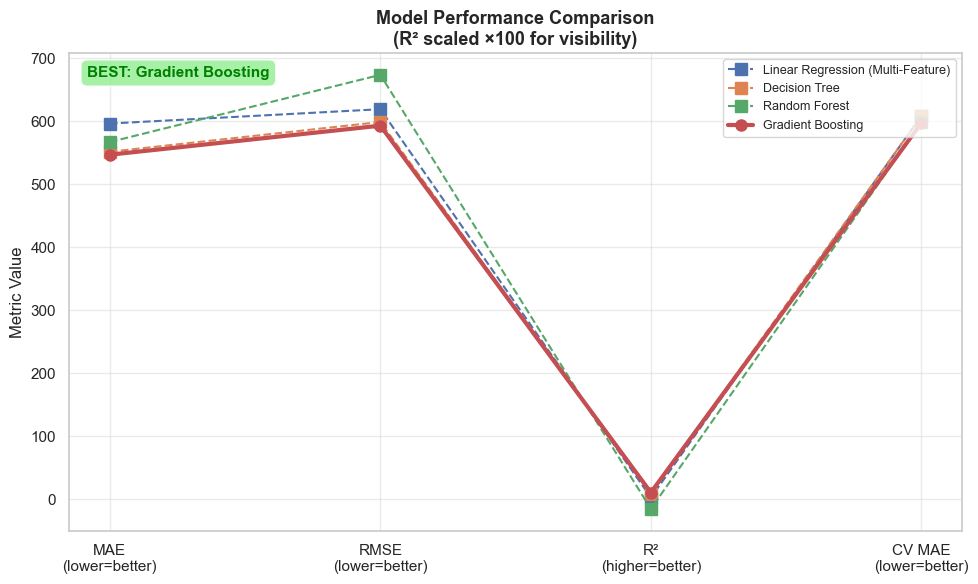


Best model saved as 'best_model.pkl'
Scaler saved as     'scaler.pkl'
Ready for deployment!


In [30]:
# --- Scoring Logic ---
# Lower MAE + Lower RMSE + Higher R² = Better model
# We rank by RMSE (primary), MAE (secondary), R² (tertiary)

print("\n" + "=" * 55)
print("         BEST MODEL SELECTION REPORT")
print("=" * 55)

# Rank improved models only
improved_df = comparison_df[comparison_df['Type'] == 'Improved'].copy()
improved_df['Rank_MAE']  = improved_df['MAE'].rank()
improved_df['Rank_RMSE'] = improved_df['RMSE'].rank()
improved_df['Rank_R2']   = improved_df['R²'].rank(ascending=False)
improved_df['Total_Rank'] = (improved_df['Rank_MAE'] +
                              improved_df['Rank_RMSE'] +
                              improved_df['Rank_R2'])

best_row  = improved_df.loc[improved_df['Total_Rank'].idxmin()]
best_name = best_row['Model'].replace('\n', ' ')

print(f"\n  Winner : {best_name}")
print(f"  MAE    : {best_row['MAE']} minutes")
print(f"  RMSE   : {best_row['RMSE']} minutes")
print(f"  R²     : {best_row['R²']}")
print(f"  CV MAE : {best_row['CV MAE']} minutes")

# --- Improvement over Basic Model ---
mae_improvement  = ((mae_basic  - best_row['MAE'])  / mae_basic)  * 100
rmse_improvement = ((rmse_basic - best_row['RMSE']) / rmse_basic) * 100
r2_improvement   = ((best_row['R²'] - r2_basic) / abs(r2_basic))  * 100

print(f"\n  Improvement over Basic Model:")
print(f"    MAE  improved by : {mae_improvement:.1f}%")
print(f"    RMSE improved by : {rmse_improvement:.1f}%")
print(f"    R²   improved by : {r2_improvement:.1f}%")
print("=" * 55)

# --- Final Ranking Table ---
print("\n=== Final Model Rankings (Improved Models) ===")
rank_display = improved_df[['Model', 'MAE', 'RMSE', 'R²',
                              'CV MAE', 'Total_Rank']].sort_values('Total_Rank')
rank_display['Model'] = rank_display['Model'].str.replace('\n', ' ')
rank_display['Rank']  = range(1, len(rank_display) + 1)
print(rank_display[['Rank', 'Model', 'MAE', 'RMSE', 'R²', 'CV MAE']].to_string(index=False))

# -------------------------------------------------------
# VISUAL — Final Radar Chart for Best Model Selection
# -------------------------------------------------------
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 6))

metrics      = ['MAE\n(lower=better)', 'RMSE\n(lower=better)', 'R²\n(higher=better)', 'CV MAE\n(lower=better)']
x_positions  = range(len(metrics))

for idx, (_, row) in enumerate(improved_df.iterrows()):
    name   = row['Model'].replace('\n', ' ')
    values = [row['MAE'], row['RMSE'], row['R²'] * 100, row['CV MAE']]
    style  = '-o' if row['Model'] == best_row['Model'] else '--s'
    lw     = 3 if row['Model'] == best_row['Model'] else 1.5
    ax.plot(x_positions, values, style, linewidth=lw,
            markersize=8, label=name)

ax.set_xticks(x_positions)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_title('Model Performance Comparison\n(R² scaled ×100 for visibility)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Metric Value')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.4)

# Highlight best model name
ax.annotate(f'BEST: {best_name}',
            xy=(0.02, 0.95), xycoords='axes fraction',
            fontsize=11, color='green', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig('task5_4_best_model_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Save Best Model for future use ---
import joblib
best_model_obj = improved_results[best_row['Model']]['model']
joblib.dump(best_model_obj,  'best_model.pkl')
joblib.dump(scaler_multi,    'scaler.pkl')
joblib.dump(X_full.columns.tolist(), 'feature_names.pkl')

print(f"\nBest model saved as 'best_model.pkl'")
print(f"Scaler saved as     'scaler.pkl'")
print(f"Ready for deployment!")